In [146]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


# EDA

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [7]:
corr=data.corr(numeric_only=True)
corr

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


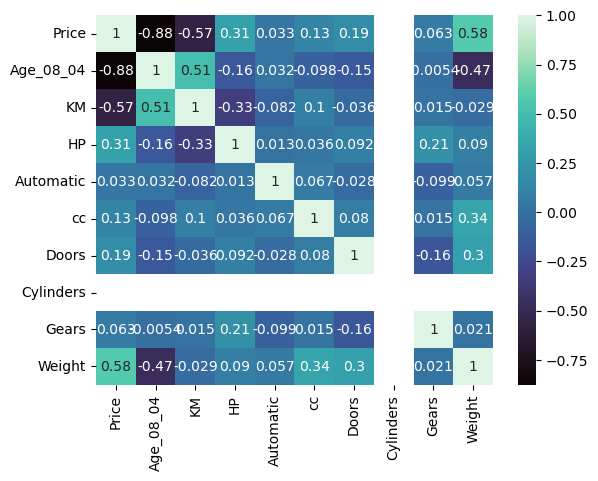

In [8]:
sns.heatmap(corr,cmap='mako',annot=True)
plt.show()

In [9]:
data1=data.copy()

In [13]:
data1['Cylinders'].nunique()

1

In [22]:
#data1.drop('Cylinders',axis=1,inplace=True)
data1.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,5,1170


In [23]:
data1.duplicated().sum()

np.int64(1)

In [24]:
data1[data1.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,5,1320


In [25]:
data1.drop_duplicates(inplace=True,ignore_index=True)

In [26]:
data1.duplicated().sum()

np.int64(0)

In [27]:
data2=data1.copy()

In [28]:
data2= pd.get_dummies(data2, columns=['Fuel_Type'], drop_first=True)

In [29]:
data2

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,True,False
1,13750,23,72937,90,0,2000,3,5,1165,True,False
2,13950,24,41711,90,0,2000,3,5,1165,True,False
3,14950,26,48000,90,0,2000,3,5,1165,True,False
4,13750,30,38500,90,0,2000,3,5,1170,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,86,0,1300,3,5,1025,False,True
1431,10845,72,19000,86,0,1300,3,5,1015,False,True
1432,8500,71,17016,86,0,1300,3,5,1015,False,True
1433,7250,70,16916,86,0,1300,3,5,1015,False,True


Outlier detection report:

Price: 109 outliers
Age_08_04: 7 outliers
KM: 49 outliers
HP: 11 outliers
Automatic: 80 outliers
cc: 122 outliers
Doors: 0 outliers
Gears: 46 outliers
Weight: 65 outliers

 Boxplot visualization for each numeric column:



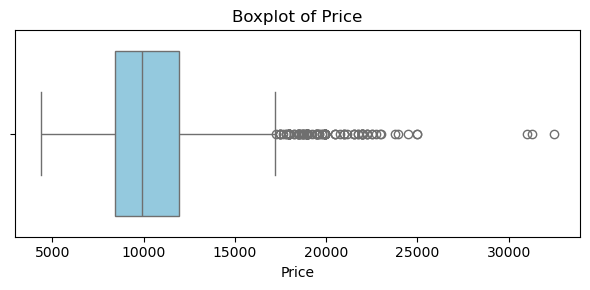

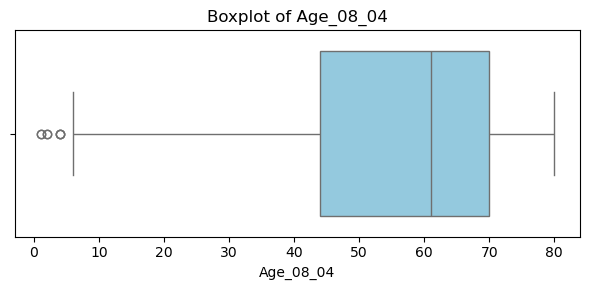

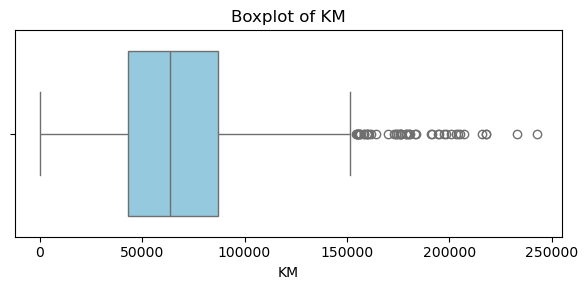

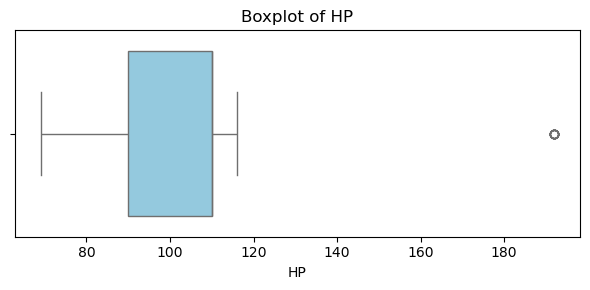

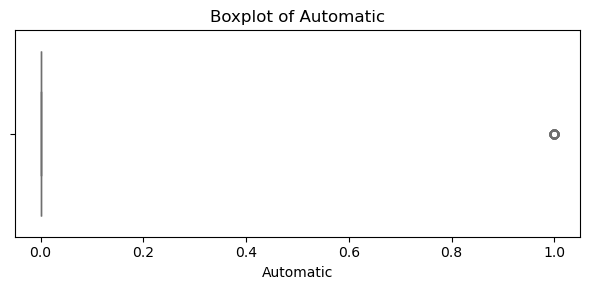

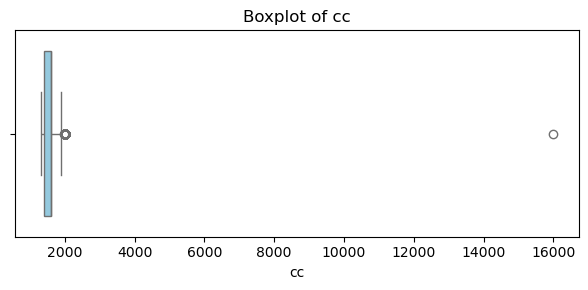

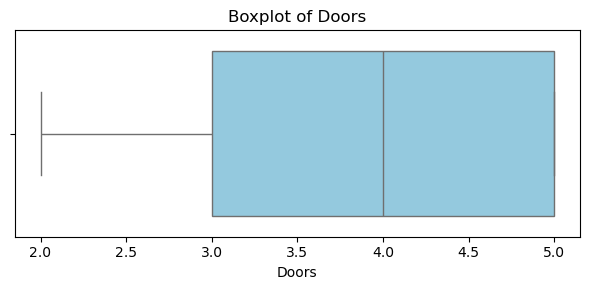

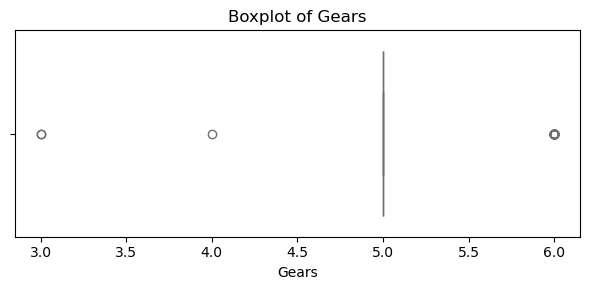

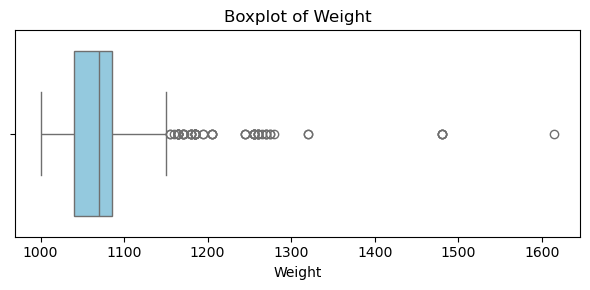

C:\Users\hp\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)
C:\Users\hp\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)



Outlier treatment completed for all numeric columns.

Boxplots after outlier treatment:



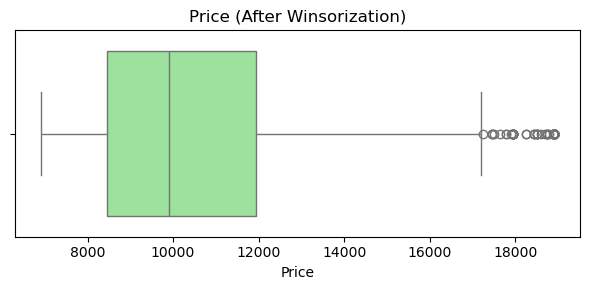

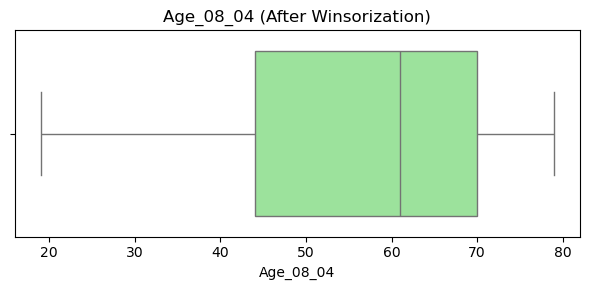

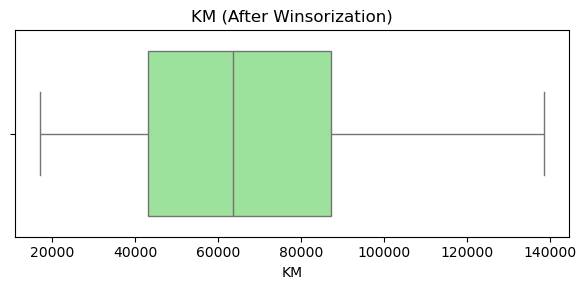

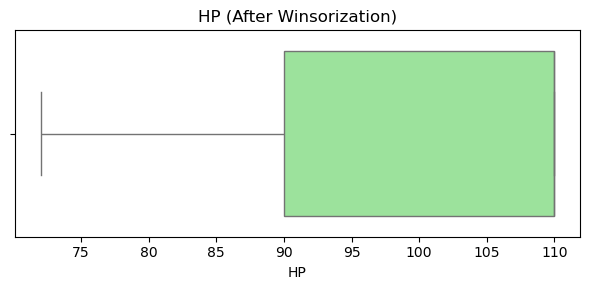

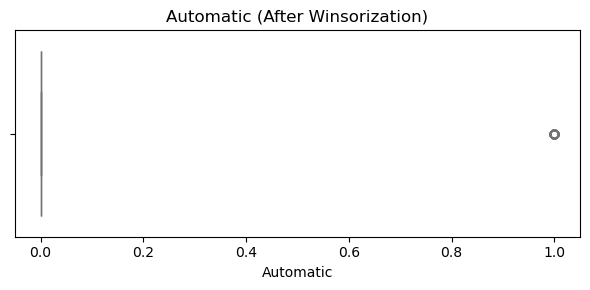

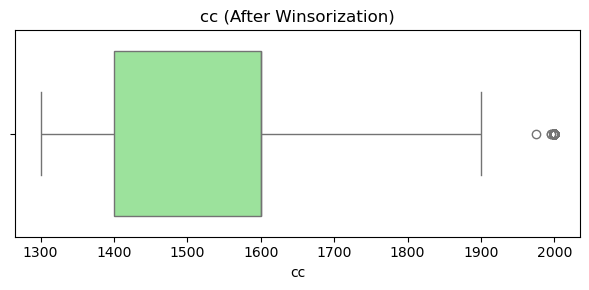

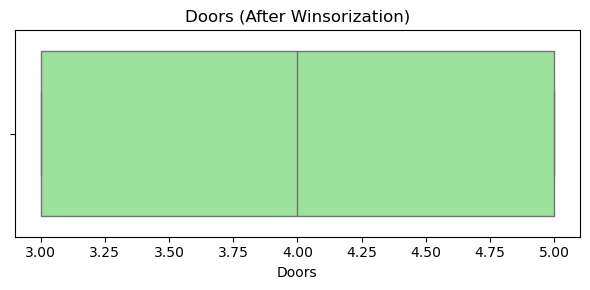

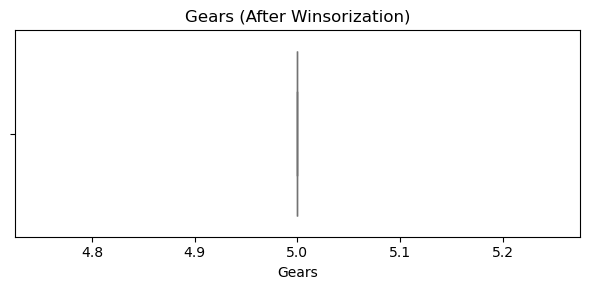

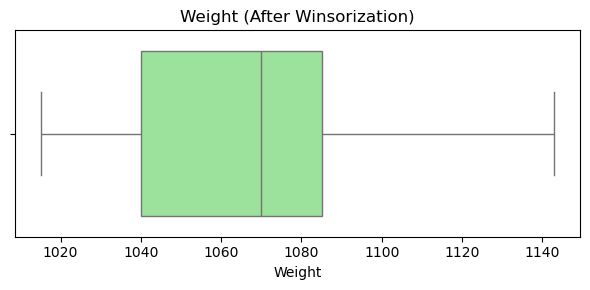

In [33]:
# Select only numeric columns
numeric_cols = data2.select_dtypes(include=['int64', 'float64']).columns


# Step 1: Detect outliers (IQR method)

print("Outlier detection report:\n")
outlier_counts = {}

for col in numeric_cols:
    Q1 = data2[col].quantile(0.25)
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data2[(data2[col] < lower) | (data2[col] > upper)]
    outlier_counts[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")


# Step 2: Simple visual check for each column

print("\n Boxplot visualization for each numeric column:\n")

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data2[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


# Step 3: Handle outliers (Winsorization)
# Clip values outside 5th–95th percentile

for col in numeric_cols:
    lower = data2[col].quantile(0.05)
    upper = data2[col].quantile(0.95)
    data2[col] = np.clip(data2[col], lower, upper)

print("\nOutlier treatment completed for all numeric columns.\n")


# Step 4: Visualize again after winsorization

print("Boxplots after outlier treatment:\n")

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data2[col], color="lightgreen")
    plt.title(f"{col} (After Winsorization)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


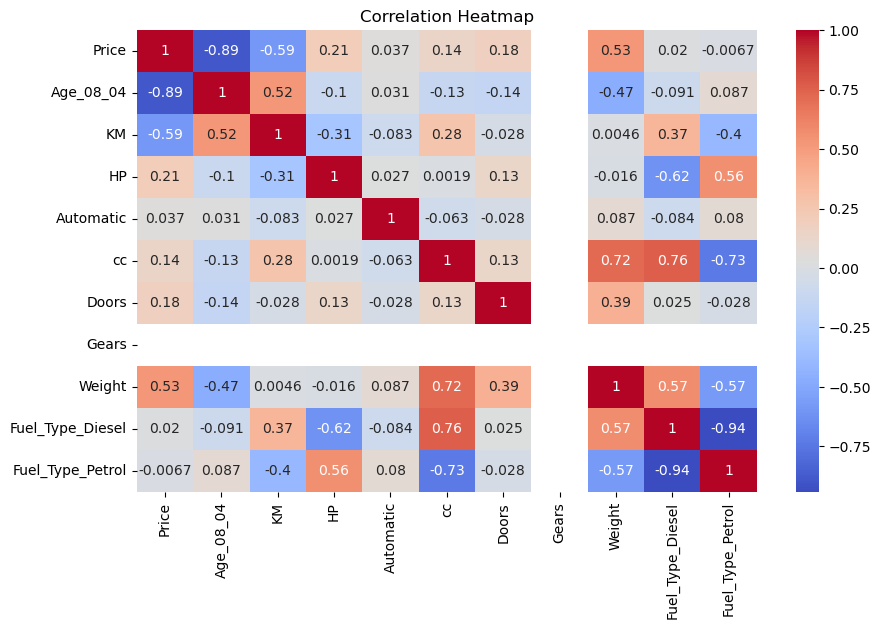

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(data2.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Model Building

### Model 1-Using all features

In [260]:
x=data2.iloc[:,1:]
y=data2['Price']

In [261]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1148, 10), (287, 10), (1148,), (287,))

In [262]:
lreg=LinearRegression()

In [263]:
lreg.fit(x_train,y_train)

LinearRegression()

In [264]:
#evaluate the model
def evaluate_reg(y,yhat):
    mse=mean_squared_error(y,yhat)
    rmse=np.sqrt(mse)
    r2_val=r2_score(y,yhat)
    print(f'mse:{np.round(mse,2)}')
    print(f'rmse:{np.round(rmse,2)}')
    print(f'r score value:{np.round(r2_val,2)}')
    return mse,rmse,r2_val

In [265]:
#evaluate model on training data
yhat_train=lreg.predict(x_train)

In [266]:
train_mse,train_rmse,Train_re=evaluate_reg(y_train,yhat_train)

mse:1420818.12
rmse:1191.98
r score value:0.86


In [268]:
#evaluate the model on testing data
yhat_test=lreg.predict(x_test)

In [269]:
test_mse,test_rmse,test_re=evaluate_reg(y_test,yhat_test)

mse:1312111.05
rmse:1145.47
r score value:0.87


#### The model performs well with similar training (R² = 0.86) and testing (R² = 0.87) scores, showing good generalization. The close MSE and RMSE values indicate low error and suggest that the model predicts accurately without overfitting.

In [270]:
lreg.coef_

array([-1.18335208e+02, -1.61876869e-02,  2.03525781e+01,  3.43889992e+00,
       -2.05762367e+00, -1.78796804e+02, -1.30739863e-12,  3.17435569e+01,
        8.35697320e+02,  1.44243494e+03])

In [271]:
lasso=Lasso(alpha=1.0,)
lasso.fit(x,y)

Lasso()

In [272]:
lasso.coef_

array([-1.19228662e+02, -1.66065953e-02,  1.76880088e+01, -6.86676085e+00,
       -1.74496877e+00, -1.49639237e+02,  0.00000000e+00,  3.06426952e+01,
        7.09052116e+02,  1.30655465e+03])

In [273]:
ridge=Ridge(alpha=1.0,)
ridge.fit(x,y)

Ridge()

In [274]:
ridge.coef_

array([-1.19023603e+02, -1.65746765e-02,  1.94578727e+01, -2.70682125e+01,
       -1.90208049e+00, -1.52882523e+02,  0.00000000e+00,  3.08234050e+01,
        8.60534613e+02,  1.35162236e+03])

In [275]:
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Linear': lreg.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_
})
coef_df

,Feature,Linear,Lasso,Ridge
0,Age_08_04,-1.183352e+02,-119.228662,-119.023603
1,KM,-1.618769e-02,-0.016607,-0.016575
2,HP,2.035258e+01,17.688009,19.457873
3,Automatic,3.438900e+00,-6.866761,-27.068213
4,cc,-2.057624e+00,-1.744969,-1.902080
5,Doors,-1.787968e+02,-149.639237,-152.882523
6,Gears,-1.307399e-12,0.000000,0.000000
7,Weight,3.174356e+01,30.642695,30.823405
8,Fuel_Type_Diesel,8.356973e+02,709.052116,860.534613
9,Fuel_Type_Petrol,1.442435e+03,1306.554646,1351.622363


### Model 2 -Using Selected Features

In [276]:
data2.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986.0,90,0,2000,3,5,1143,True,False
1,13750,23,72937.0,90,0,2000,3,5,1143,True,False
2,13950,24,41711.0,90,0,2000,3,5,1143,True,False
3,14950,26,48000.0,90,0,2000,3,5,1143,True,False
4,13750,30,38500.0,90,0,2000,3,5,1143,True,False


In [277]:
x=data2.iloc[:,[1,2,3,8,9,10]]
y=data2['Price']

In [278]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1148, 6), (287, 6), (1148,), (287,))

In [279]:
lreg.fit(x_train,y_train)

LinearRegression()

In [280]:
#evaluate model on training data
yhat_train=lreg.predict(x_train)
train_mse,train_rmse,Train_re=evaluate_reg(y_train,yhat_train)

mse:1413161.27
rmse:1188.76
r score value:0.86


In [281]:
#evaluate the model on testing data
yhat_test=lreg.predict(x_test)
test_mse,test_rmse,test_re=evaluate_reg(y_test,yhat_test)

mse:1438666.86
rmse:1199.44
r score value:0.86


#### The model performs well with an R² of 0.86, explaining 86% of the target’s variance. The RMSE (~1190) shows a moderate prediction error, and similar train-test results indicate good generalization without overfitting.

In [282]:
lreg.coef_

array([-1.22104964e+02, -1.66438981e-02,  3.55462722e+00,  2.56424352e+01,
        9.97358834e+00,  1.45953007e+03])

In [283]:
lasso=Lasso(alpha=1.0,)
lasso.fit(x,y)

Lasso()

In [284]:
lasso.coef_

array([-1.21906743e+02, -1.72374679e-02,  1.53139150e+00,  2.62393295e+01,
       -1.47554924e+02,  1.33750768e+03])

In [285]:
ridge=Ridge(alpha=1.0,)
ridge.fit(x,y)

Ridge()

In [286]:
ridge.coef_

array([-1.21873759e+02, -1.72325030e-02,  1.10810194e+00,  2.63577125e+01,
       -2.33459695e+02,  1.27805463e+03])

In [287]:
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Linear': lreg.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_
})
coef_df

,Feature,Linear,Lasso,Ridge
0,Age_08_04,-122.104964,-121.906743,-121.873759
1,KM,-0.016644,-0.017237,-0.017233
2,HP,3.554627,1.531391,1.108102
3,Weight,25.642435,26.239329,26.357713
4,Fuel_Type_Diesel,9.973588,-147.554924,-233.459695
5,Fuel_Type_Petrol,1459.530075,1337.507679,1278.054632


### Model 3-Using Polynomial Regression

In [230]:
x=data2.iloc[:,[1,2,3,8,9,10]]
y=data2['Price']

In [231]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1148, 6), (287, 6), (1148,), (287,))

In [232]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(x_train)
X_poly_test = poly.transform(x_test)

In [233]:
scaler = StandardScaler()
X_poly_train_scaled = scaler.fit_transform(X_poly_train)
X_poly_test_scaled = scaler.transform(X_poly_test)

In [234]:
lreg = LinearRegression()
lreg.fit(X_poly_train_scaled, y_train)

LinearRegression()

In [235]:
yhat_train = lreg.predict(X_poly_train_scaled)
train_mse, train_rmse, train_r2 = evaluate_reg(y_train, yhat_train)

mse:1060683.39
rmse:1029.89
r score value:0.9


In [236]:
yhat_test = lreg.predict(X_poly_test_scaled)
test_mse, test_rmse, test_r2 = evaluate_reg(y_test, yhat_test)

mse:1147371.39
rmse:1071.15
r score value:0.86


#### The model performs well with R² = 0.90 (train) and 0.86 (test), showing strong predictive accuracy and minimal overfitting. The small rise in MSE and RMSE on the test set indicates good generalization.

In [237]:
lasso = Lasso(alpha=0.5, max_iter=50000, random_state=42)
lasso.fit(X_poly_train_scaled, y_train)

Lasso(alpha=0.5, max_iter=50000, random_state=42)

In [238]:
lasso.coef_

array([ 6377.18439225,    -0.        ,   894.29905446,    -0.        ,
          -0.        ,     0.        ,   851.93636   ,   953.81185252,
       -2611.93941295, -6628.44286868,  -682.1489445 ,  -495.14125615,
        -432.76394523,   812.70450824, -2181.02054382,   641.45685961,
         469.52163889,    -0.        ,    65.57627507,   157.75715226,
          -0.        ,  1651.58012883,     0.        ,    90.12627761,
          -0.        ,     0.        ,     0.        ])

In [239]:
lreg.coef_

array([ 9666.10739515, -2354.50991061,  6038.80390586, -5277.75432107,
       -3096.23559916, -5202.32661597,   547.71498296,  1025.12252623,
       -2972.39803616, -8806.23558445, -1055.88292356, -1016.5996526 ,
        -426.55341577,   791.17988883,  -269.8413649 ,  1024.85908615,
         954.03468582, -1554.4646107 , -1896.68001515, -2937.00567619,
       -4141.9165387 ,  6153.52896248, 10738.84362743, 14217.03719027,
       -3096.23559916,     0.        , -5202.32661597])

In [240]:
Ridge(alpha=10.0, random_state=42)
ridge.fit(X_poly_train_scaled, y_train)

Ridge()

In [241]:
ridge.coef_

array([ 1186.1100576 ,  -245.77791205,   216.37166077,  -234.91042414,
        -100.01365618,   -55.06474909,  1304.79899979,   941.60620618,
       -2419.29465166, -2412.09578405,  -660.82891644,  -260.47226367,
        -434.96500311,   557.06458356, -1615.19117113,   542.61150855,
         466.03798956,    92.15091387,   676.18095576,   172.68814738,
        -199.50395521,  1235.6540733 ,   230.19744728,   249.91781237,
        -100.01365618,     0.        ,   -55.06474909])

In [242]:
coef_comparison = pd.DataFrame({
    'Feature': poly.get_feature_names_out(x_train.columns),
    'Linear': lreg.coef_.flatten(),
    'Lasso': lasso.coef_.flatten(),
    'Ridge': ridge.coef_.flatten()
})

coef_comparison


,Feature,Linear,Lasso,Ridge
0,Age_08_04,9666.107395,6377.184392,1186.110058
1,KM,-2354.509911,-0.000000,-245.777912
2,HP,6038.803906,894.299054,216.371661
3,Weight,-5277.754321,-0.000000,-234.910424
4,Fuel_Type_Diesel,-3096.235599,-0.000000,-100.013656
5,Fuel_Type_Petrol,-5202.326616,0.000000,-55.064749
6,Age_08_04^2,547.714983,851.936360,1304.799000
7,Age_08_04 KM,1025.122526,953.811853,941.606206
8,Age_08_04 HP,-2972.398036,-2611.939413,-2419.294652
9,Age_08_04 Weight,-8806.235584,-6628.442869,-2412.095784


##### 1️ Normalization & Standardization:⃣ 

###### Normalization scales data to a range (usually 0–1), while Standardization centers data to mean 0 and variance 1. They help ensure all features contribute equally, improving model accuracy and convergence, especially in linear and distance-based models.

##### Handling Multicollinearity:

###### Remove or combine correlated features, use PCA for dimensionality reduction, or apply regularization methods like Ridge and Lasso to stabilize coefficients and improve model reliability.